In [1]:
# installations for colab
!pip install fiftyone torch torchvision google

## Data Import 

In [2]:
# package fiftyone handles all file management for downloading automatically
import fiftyone.zoo as foz

my_classes = ["Coffee", "Ice cream", "Candy"]

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=my_classes,
    max_samples=2000,
    shuffle=True
)

Necessary images already downloaded
Existing download of split 'train' is sufficient
Loading existing dataset 'open-images-v7-train-2000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [ ]:
# # Use this code to export the dataset to a directory tree format for use in PyTorch
# # processing adapted from 00-project on moodle
# import fiftyone as fo
# from fiftyone import ViewField as F
# import shutil
# import os

# dataset = dataset.filter_labels("ground_truth", F("label").is_in(my_classes))

# export_dir = r"C:\Users\**\Desktop\Image\Image-Classification\project-2026"

# # remove previous export if it exists
# if os.path.exists(export_dir):
#     shutil.rmtree(export_dir)
#     print("Cleared old export")

# patches = dataset.to_patches("ground_truth")

# patches.export(
#     export_dir=export_dir,
#     dataset_type=fo.types.ImageClassificationDirectoryTree,
#     label_field="ground_truth"
# )

Cleared old export
Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...
 100% |███████████████| 3892/3892 [34.5s elapsed, 0s remaining, 129.1 samples/s]      


In [ ]:
# processing adapted from 00-project on moodle
# downloads and stores the data in a google drive folder
import fiftyone as fo
from fiftyone import ViewField as F
from google.colab import drive
import shutil
import os

dataset = dataset.filter_labels("ground_truth", F("label").is_in(my_classes))

export_dir = "/content/drive/MyDrive/project-2026"

# removing previous download if exists
if os.path.exists(export_dir):
    shutil.rmtree(export_dir)
    print("Cleared old export")
    
patches = dataset.to_patches("ground_truth")

drive.mount('/content/drive')

export_dir = "/content/drive/MyDrive/project-2026"

patches.export(export_dir=export_dir,
            dataset_type=fo.types.ImageClassificationDirectoryTree,
            label_field="ground_truth")

## Data Exploration

In [5]:
print(dataset.first())

<SampleView: {
    'id': '69d5bee181662a622955b8bc',
    'media_type': 'image',
    'filepath': 'C:\\Users\\Mert\\fiftyone\\open-images-v7\\train\\data\\35c99750a93c1938.jpg',
    'tags': ['train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 263389,
        'mime_type': 'image/jpeg',
        'width': 1024,
        'height': 1024,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 4, 8, 2, 35, 13, 487000),
    'last_modified_at': datetime.datetime(2026, 4, 8, 2, 53, 49, 410000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '69d5bee181662a622955b8b8',
                'attributes': {},
                'tags': [],
                'label': 'Ice cream',
                'bounding_box': [0.048437, 0.557813, 0.535938, 0.420312],
                'mask': None,
                'mask_path': None,
                'confidence': None,
                'index': None,
                'IsOccluded': False,


In [6]:
from collections import Counter

label_counts = Counter()

for sample in dataset:
    if sample.ground_truth is None:
        continue
    for det in sample.ground_truth.detections:
        if det.label in my_classes:
            label_counts[det.label] += 1

print("Label Distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Distribution:
Ice cream: 1451
Candy: 1294
Coffee: 1147


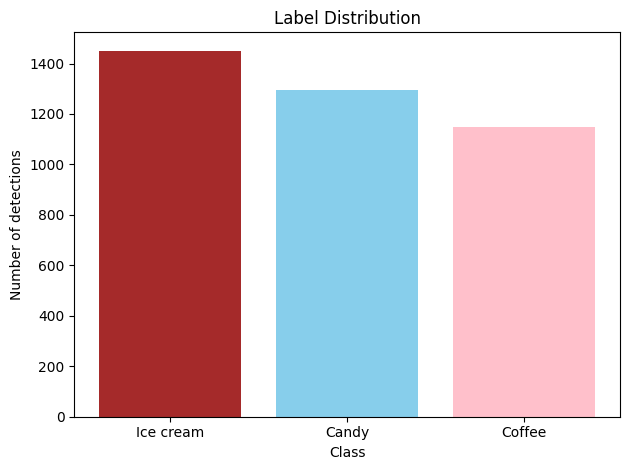

In [7]:
import matplotlib.pyplot as plt

plt.bar(label_counts.keys(), label_counts.values(), color=["brown", "skyblue", "pink"])
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of detections")
plt.tight_layout()
plt.show()

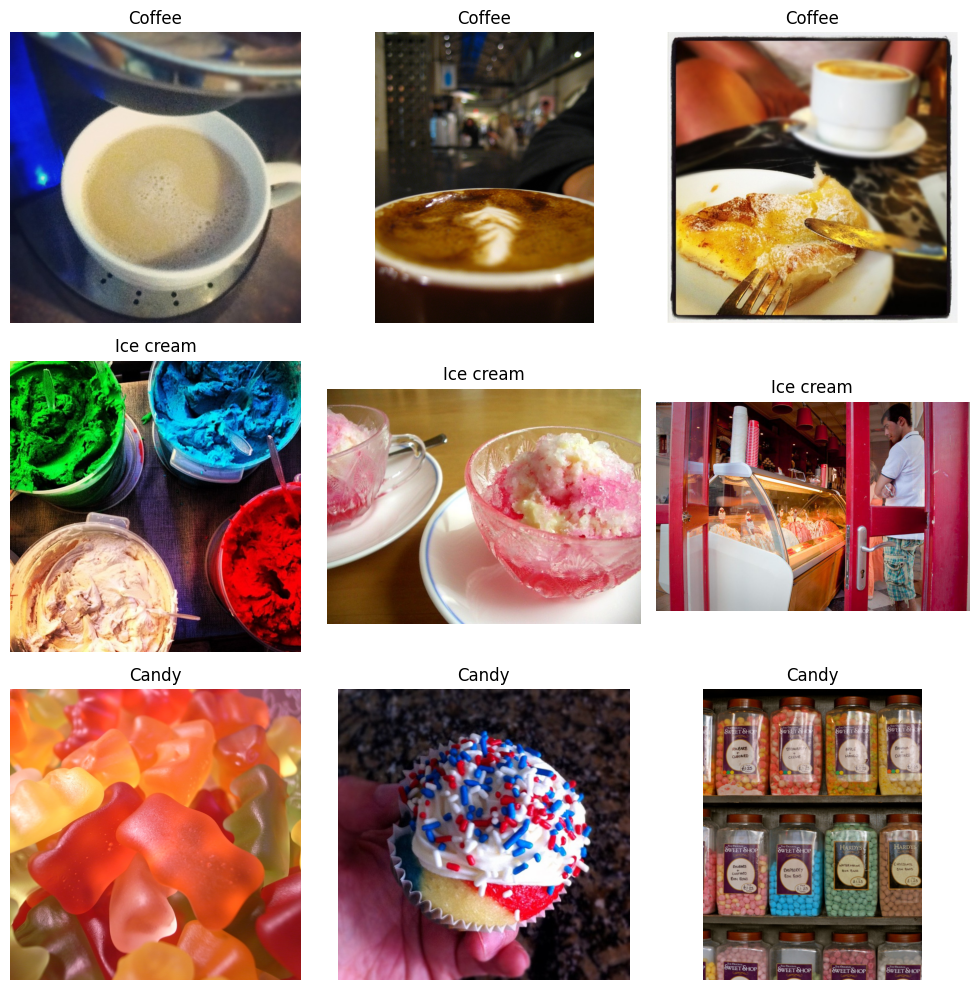

In [8]:
from PIL import Image
# looking at sample images per class
fig, axes = plt.subplots(len(my_classes), 3, figsize=(10, 10))

for row, cls in enumerate(my_classes):
    shown = 0
    for sample in dataset:
        if shown == 3:
            break
        if sample.ground_truth is None:
            continue
        labels = [d.label for d in sample.ground_truth.detections]
        if cls in labels:
            img = Image.open(sample.filepath).convert("RGB")
            axes[row, shown].imshow(img)
            axes[row, shown].set_title(cls)
            axes[row, shown].axis("off")
            shown += 1

plt.tight_layout()
plt.show()

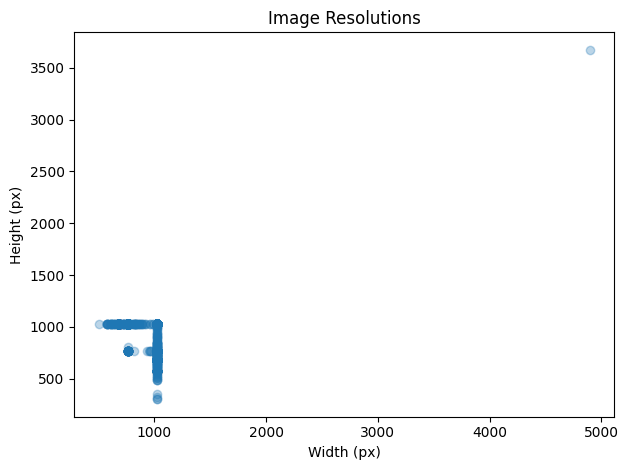

In [9]:
import matplotlib.pyplot as plt

dataset.compute_metadata()

widths_px = []
heights_px = []

for sample in dataset:
    if sample.metadata is not None:
        widths_px.append(sample.metadata.width)
        heights_px.append(sample.metadata.height)

plt.scatter(widths_px, heights_px, alpha=0.3)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Resolutions")
plt.tight_layout()
plt.show()

In [10]:
# looking at how "cluttered" the images are on average, could affect training/performance
import numpy as np

objects_per_image = []

for sample in dataset:
    if sample.ground_truth is None:
        continue
    count = sum(1 for det in sample.ground_truth.detections if det.label in my_classes)
    objects_per_image.append(count)

print("Analysis of objects per image:")
print(f"Average objects per image: {np.mean(objects_per_image):.2f}")
print(f"Max objects in one image: {max(objects_per_image)}")

Analysis of objects per image:
Average objects per image: 1.95
Max objects in one image: 45


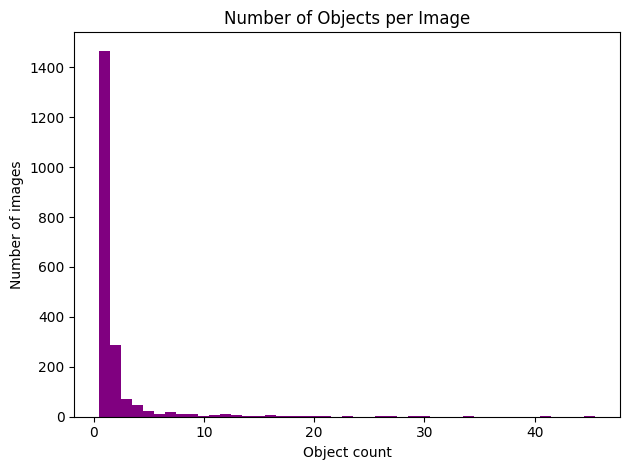

In [11]:
plt.hist(objects_per_image, bins=range(1, max(objects_per_image)+2), color="purple", align="left")
plt.title("Number of Objects per Image")
plt.xlabel("Object count")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

In [12]:
from PIL import Image

widths_px, heights_px = [], []

for sample in dataset:
    with Image.open(sample.filepath) as img:
        w, h = img.size
        widths_px.append(w)
        heights_px.append(h)

print("Image Resolution Distribution:")
print(f"Width  — min: {min(widths_px)}, max: {max(widths_px)}, mean: {np.mean(widths_px):.0f}")
print(f"Height — min: {min(heights_px)}, max: {max(heights_px)}, mean: {np.mean(heights_px):.0f}")

Image Resolution Distribution:
Width  — min: 505, max: 4896, mean: 968
Height — min: 303, max: 3672, mean: 844


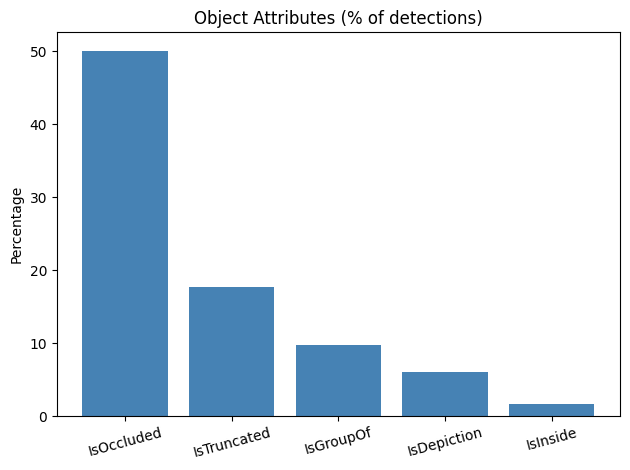

In [13]:
attributes = ["IsOccluded", "IsTruncated", "IsGroupOf", "IsDepiction", "IsInside"]

attr_counts = {attr: 0 for attr in attributes}
total = 0

for sample in dataset:
    if sample.ground_truth is None:
        continue
    for det in sample.ground_truth.detections:
        if det.label in my_classes:
            total += 1
            for attr in attributes:
                if getattr(det, attr, False):
                    attr_counts[attr] += 1

attr_pct = {k: v/total*100 for k, v in attr_counts.items()}

plt.bar(attr_pct.keys(), attr_pct.values(), color="steelblue")
plt.title("Object Attributes (% of detections)")
plt.ylabel("Percentage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## VGG19-Network

In [14]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

In [15]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG19 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# with augmentation
augment_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(15),           
    transforms.RandomAffine(0, translate=(0.1, 0.1)),  
    transforms.RandomCrop(224),              
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [16]:
# simplified loading following given 
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

full_dataset = ImageFolder(root=export_dir, transform=base_transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(full_dataset.class_to_idx)

{'Candy': 0, 'Coffee': 1, 'Ice cream': 2}


In [17]:
def build_vgg19(pretrained=False, num_classes=3):
    weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.vgg19(weights=weights)
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

model_scratch = build_vgg19(pretrained=False)
model_pretrained = build_vgg19(pretrained=True)   # for transfer learning experiment

In [18]:
def train(model, loader, test_loader, epochs=10, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (out.argmax(1) == lbls).sum().item()
            total += lbls.size(0)

        train_acc = correct / total
        test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(total_loss / len(loader))
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return history

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return correct / total

## Comparing training base model vs transfer learning

In [ ]:
# # Outcomment this code if you want to check GPU availability and details before training
# import torch

# print("Torch version:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# print("CUDA version in torch:", torch.version.cuda)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)
# if torch.cuda.is_available():
#     print(torch.cuda.get_device_name(0))

print("Training from scratch:")
history_scratch = train(model_scratch, train_loader, test_loader, epochs=10)

print("Transfer learning:")
history_pretrained = train(model_pretrained, train_loader, test_loader, epochs=10)

Torch version: 2.11.0+cu128
CUDA available: True
CUDA version in torch: 12.8
Using device: cuda
NVIDIA GeForce RTX 3060
Training from scratch:
Epoch 1/10 | Loss: 0.3773 | Train Acc: 0.8538 | Test Acc: 0.8062
Epoch 2/10 | Loss: 0.3072 | Train Acc: 0.8863 | Test Acc: 0.8010
Epoch 3/10 | Loss: 0.2760 | Train Acc: 0.8969 | Test Acc: 0.7561
Epoch 4/10 | Loss: 0.2346 | Train Acc: 0.9097 | Test Acc: 0.7908
Epoch 5/10 | Loss: 0.2017 | Train Acc: 0.9248 | Test Acc: 0.8062
Epoch 6/10 | Loss: 0.2033 | Train Acc: 0.9223 | Test Acc: 0.7728
Epoch 7/10 | Loss: 0.1517 | Train Acc: 0.9457 | Test Acc: 0.7869
Epoch 8/10 | Loss: 0.1237 | Train Acc: 0.9570 | Test Acc: 0.7933
Epoch 9/10 | Loss: 0.1322 | Train Acc: 0.9531 | Test Acc: 0.7856
Epoch 10/10 | Loss: 0.0953 | Train Acc: 0.9692 | Test Acc: 0.7946
Transfer learning:
Epoch 1/10 | Loss: 0.1017 | Train Acc: 0.9724 | Test Acc: 0.9332
Epoch 2/10 | Loss: 0.0723 | Train Acc: 0.9798 | Test Acc: 0.9140
Epoch 3/10 | Loss: 0.0679 | Train Acc: 0.9765 | Test Acc:

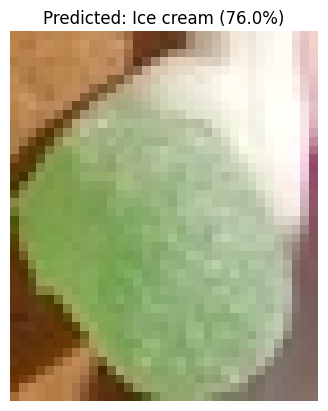

Candy: 23.5%
Coffee: 0.6%
Ice cream: 76.0%


In [37]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# demonstration function for prediction that also prints image 
def predict_image(model, image_path, transform):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        
    class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
    
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_idx]} ({probs[pred_idx]:.1%})")
    plt.axis("off")
    plt.show()

    for name, prob in zip(class_names, probs):
        print(f"{name}: {prob:.1%}")

test_image_path = test_dataset.dataset.samples[test_dataset.indices[0]][0]
predict_image(model_pretrained, test_image_path, base_transform)

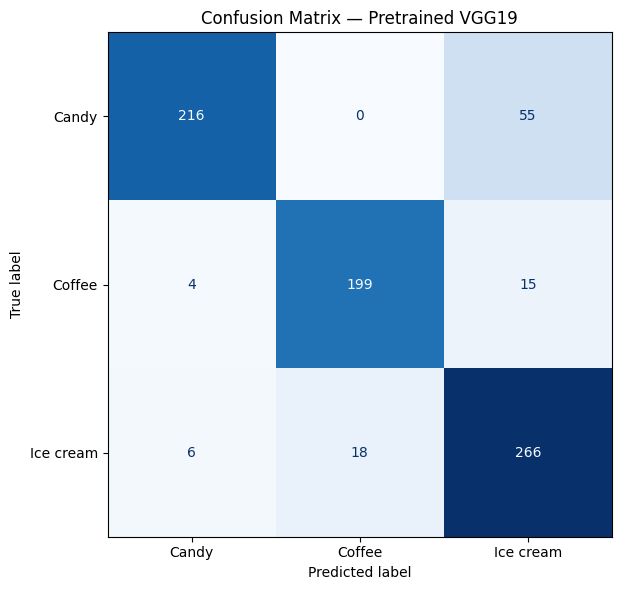

In [21]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix — Pretrained VGG19")
    plt.tight_layout()
    plt.show()

class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
plot_confusion_matrix(model_pretrained, test_loader, class_names)

## Experiments with Data Augmentation

In [22]:
# random rotate, random translate, random crop

## Experiments with Architecture

Rebuild VGG19. After layer block4_conv4 (32, 32,
512):
● Add the following bottleneck layer (padding same)
● Add conv layer (kernel 1x1, filters 1024, padding valid, stride 1, activation
leaky relu)
● Add conv layer (kernel 3x3, filters 1024, padding same, stride 1, activation
relu)
● Freeze conv3 layers and before
● Prediction head (Flatten and fully connected layers)

In [24]:
import torch
import torch.nn as nn
from torchvision import models

class BottleneckResidualBlock(nn.Module):
    def __init__(self, in_channels=512, mid1=64, mid2=128):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid1, kernel_size=1, stride=1, padding=0),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid1, mid2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid2, in_channels, kernel_size=1, stride=1, padding=0)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = out + x
        return self.relu(out)


class ModifiedVGG19(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()

        weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained else None
        base_model = models.vgg19(weights=weights)

        # keep VGG19 up to block4_conv4
        self.features = nn.Sequential(*list(base_model.features.children())[:27])

        # freeze conv3 and before
        for idx, layer in enumerate(self.features):
            if idx <= 18:
                for param in layer.parameters():
                    param.requires_grad = False

        # bottleneck block
        self.bottleneck = BottleneckResidualBlock(in_channels=512, mid1=64, mid2=128)

        # required extra conv layers
        self.extra_conv1 = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=1, stride=1, padding=0),
            nn.LeakyReLU(inplace=True)
        )

        self.extra_conv2 = nn.Sequential(
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )

        # prediction head
        self.pool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.bottleneck(x)
        x = self.extra_conv1(x)
        x = self.extra_conv2(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model_arch = ModifiedVGG19(num_classes=3, pretrained=True)
history_arch = train(model_arch, train_loader, test_loader, epochs=10, lr=1e-4)

Epoch 1/10 | Loss: 0.4334 | Train Acc: 0.8310 | Test Acc: 0.9101
Epoch 2/10 | Loss: 0.2127 | Train Acc: 0.9207 | Test Acc: 0.9268
Epoch 3/10 | Loss: 0.1416 | Train Acc: 0.9451 | Test Acc: 0.9307
Epoch 4/10 | Loss: 0.1183 | Train Acc: 0.9570 | Test Acc: 0.9191
Epoch 5/10 | Loss: 0.1165 | Train Acc: 0.9611 | Test Acc: 0.9037
Epoch 6/10 | Loss: 0.0926 | Train Acc: 0.9708 | Test Acc: 0.9076
Epoch 7/10 | Loss: 0.0205 | Train Acc: 0.9939 | Test Acc: 0.9345
Epoch 8/10 | Loss: 0.0163 | Train Acc: 0.9952 | Test Acc: 0.9191
Epoch 9/10 | Loss: 0.0545 | Train Acc: 0.9849 | Test Acc: 0.9384
Epoch 10/10 | Loss: 0.0844 | Train Acc: 0.9711 | Test Acc: 0.9307


### Evaluate test accuracy

In [26]:
print("Final train accuracy:", history_arch["train_acc"][-1])
print("Final test accuracy:", history_arch["test_acc"][-1])

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model_arch)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Final train accuracy: 0.9710889816896884
Final test accuracy: 0.9306803594351734
Total parameters: 46413571
Trainable parameters: 44088003


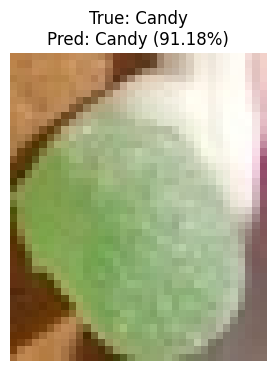

Probabilities:
Candy: 91.18%
Coffee: 0.01%
Ice cream: 8.81%


In [36]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

def predict_dataset_sample(model, dataset_obj, index, transform, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    real_index = dataset_obj.indices[index]
    img_path, true_label = dataset_obj.dataset.samples[real_index]

    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_idx]} ({probs[pred_idx].item():.2%})")
    plt.axis("off")
    plt.show()

    print("Probabilities:")
    for i, cls in enumerate(class_names):
        print(f"{cls}: {probs[i].item():.2%}")


class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
predict_dataset_sample(model_arch, test_dataset, 0, base_transform, class_names)

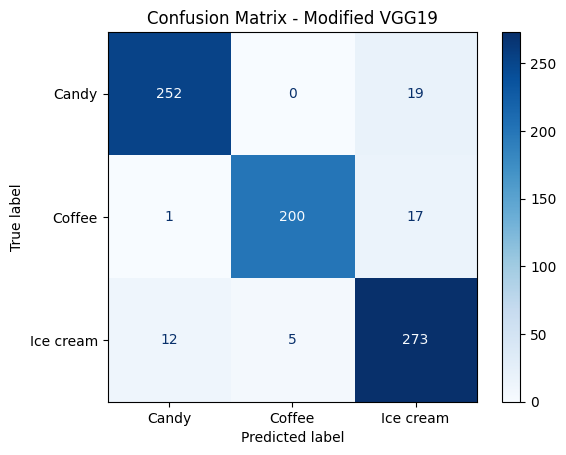

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
y_true, y_pred = get_predictions(model_arch, test_loader)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Modified VGG19")
plt.show()